In [ ]:
!pip install -q scikit-learn scipy seaborn

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
uploaded = files.upload()

Saving placement_predict_50k Dataset.csv to placement_predict_50k Dataset.csv


In [3]:
file_name = "placement_predict_50k Dataset.csv"

df = pd.read_csv(file_name)

print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)

display(df.head())

Dataset loaded successfully!
Dataset shape: (50000, 32)


,StudentID,Gender,City,CollegeTier,Stream,Specialisation,Hostel,HistoryOfBacklogs,SGPA_Sem1,SGPA_Sem2,...,Publications,AptitudeTestScore,SoftSkillsRating,CodingTestScore,MockInterviewScore,ExtraCurricular,CGPA_Tier,PlacementStatus,IsAnomaly,Salary Package
0,1,Male,Ahmedabad,Tier2,ECE,Networking,No,No,6.02,6.54,...,0,66.7,2.2,49.4,47.8,0,Low,0,0,0.00
1,2,Female,Mumbai,Tier2,ECE,DataScience,Yes,Yes,5.84,5.12,...,0,48.2,2.4,26.7,25.8,0,Low,0,0,0.00
2,3,Male,Kolkata,Tier2,IT,DataScience,Yes,No,4.91,5.29,...,0,73.8,2.8,67.7,41.5,0,Low,1,0,3.89
3,4,Male,Jaipur,Tier1,CS,AI,No,No,7.67,8.03,...,0,69.8,2.7,66.9,48.0,0,Mid,1,0,8.37
4,5,Male,Pune,Tier2,IT,DataScience,Yes,No,8.14,8.97,...,1,73.1,2.1,71.7,61.7,1,High,1,0,18.99


In [4]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nColumn names:")
print(df.columns.tolist())

print("\nDataset information:")
df.info()

Number of rows: 50000
Number of columns: 32

Column names:
['StudentID', 'Gender', 'City', 'CollegeTier', 'Stream', 'Specialisation', 'Hostel', 'HistoryOfBacklogs', 'SGPA_Sem1', 'SGPA_Sem2', 'SGPA_Sem3', 'SGPA_Sem4', 'SGPA_Sem5', 'SGPA_Sem6', 'SGPA_Sem7', 'SGPA_Sem8', 'CGPA', 'AttendancePercent', 'Internships', 'Projects', 'Workshops', 'Certifications', 'Publications', 'AptitudeTestScore', 'SoftSkillsRating', 'CodingTestScore', 'MockInterviewScore', 'ExtraCurricular', 'CGPA_Tier', 'PlacementStatus', 'IsAnomaly', 'Salary Package']

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 32 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   StudentID           50000 non-null  int64  
 1   Gender              50000 non-null  object 
 2   City                50000 non-null  object 
 3   CollegeTier         50000 non-null  object 
 4   Stream              50000 non-null

In [5]:
print("Missing values:")
missing = df.isnull().sum()

display(missing[missing > 0])

Missing values:


,0
Workshops,4488
AptitudeTestScore,4029
SoftSkillsRating,3526
CodingTestScore,2976
MockInterviewScore,4957


In [6]:
print("Duplicate rows:", df.duplicated().sum())

df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)

Duplicate rows: 0
Shape after removing duplicates: (50000, 32)


# Data Preprocessing

For this unsupervised experiment, the following columns are removed:


In [7]:
drop_columns = [
    "StudentID",
    "Salary Package",
    "IsAnomaly",
    "PlacementStatus"
]

drop_columns = [col for col in drop_columns if col in df.columns]

X = df.drop(columns=drop_columns)

print("Removed columns:", drop_columns)
print("Feature shape:", X.shape)

Removed columns: ['StudentID', 'Salary Package', 'IsAnomaly', 'PlacementStatus']
Feature shape: (50000, 28)


In [8]:
categorical_columns = X.select_dtypes(
    include=["object", "category"]
).columns.tolist()

numeric_columns = X.select_dtypes(
    include=[np.number]
).columns.tolist()

print("Categorical columns:")
print(categorical_columns)

print("\nNumerical columns:")
print(numeric_columns)

Categorical columns:
['Gender', 'City', 'CollegeTier', 'Stream', 'Specialisation', 'Hostel', 'HistoryOfBacklogs', 'CGPA_Tier']

Numerical columns:
['SGPA_Sem1', 'SGPA_Sem2', 'SGPA_Sem3', 'SGPA_Sem4', 'SGPA_Sem5', 'SGPA_Sem6', 'SGPA_Sem7', 'SGPA_Sem8', 'CGPA', 'AttendancePercent', 'Internships', 'Projects', 'Workshops', 'Certifications', 'Publications', 'AptitudeTestScore', 'SoftSkillsRating', 'CodingTestScore', 'MockInterviewScore', 'ExtraCurricular']


In [9]:
# Convert categorical variables to numerical dummy variables
X = pd.get_dummies(
    X,
    columns=categorical_columns,
    drop_first=True
)

print("Shape after encoding:", X.shape)

display(X.head())

Shape after encoding: (50000, 44)


,SGPA_Sem1,SGPA_Sem2,SGPA_Sem3,SGPA_Sem4,SGPA_Sem5,SGPA_Sem6,SGPA_Sem7,SGPA_Sem8,CGPA,AttendancePercent,...,Stream_EE,Stream_IT,Stream_Mechanical,Specialisation_DataScience,Specialisation_Embedded,Specialisation_Networking,Hostel_Yes,HistoryOfBacklogs_Yes,CGPA_Tier_Low,CGPA_Tier_Mid
0,6.02,6.54,6.52,6.00,6.47,5.91,6.49,5.50,6.29,73.3,...,False,False,False,False,False,True,False,False,True,False
1,5.84,5.12,5.34,5.18,5.03,4.93,5.40,5.13,5.23,54.5,...,False,False,False,True,False,False,True,True,True,False
2,4.91,5.29,5.49,5.73,5.33,5.88,5.82,5.67,5.52,77.6,...,False,True,False,True,False,False,True,False,True,False
3,7.67,8.03,8.08,7.64,6.86,7.10,7.56,7.39,7.51,68.8,...,False,False,False,False,False,False,False,False,False,True
4,8.14,8.97,8.36,8.55,8.55,8.38,9.10,8.86,8.65,95.8,...,False,True,False,True,False,False,True,False,False,False


In [10]:
# Handle missing values using median imputation
X = X.fillna(X.median(numeric_only=True))

# Safety fallback
if X.isnull().sum().sum() > 0:
    X = X.fillna(0)

print("Remaining missing values:", X.isnull().sum().sum())

Remaining missing values: 0


# Feature Scaling

PCA and distance-based anomaly detection methods are sensitive to feature scale.

StandardScaler transforms the features so that they have approximately:

- Mean = 0
- Standard deviation = 1

In [11]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Scaled data shape:", X_scaled.shape)

Scaled data shape: (50000, 44)


# Part A — Dimensionality Reduction using PCA



In [12]:
pca_full = PCA()

X_pca_full = pca_full.fit_transform(X_scaled)

explained_variance = pca_full.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

variance_df = pd.DataFrame({
    "Component": np.arange(1, len(explained_variance) + 1),
    "Explained Variance": explained_variance,
    "Cumulative Variance": cumulative_variance
})

display(variance_df.head(15))

,Component,Explained Variance,Cumulative Variance
0,1,0.313950,0.313950
1,2,0.057456,0.371406
2,3,0.032959,0.404365
3,4,0.031202,0.435567
4,5,0.030815,0.466382
5,6,0.028411,0.494793
6,7,0.027989,0.522783
7,8,0.026923,0.549706
8,9,0.026326,0.576032
9,10,0.026237,0.602269


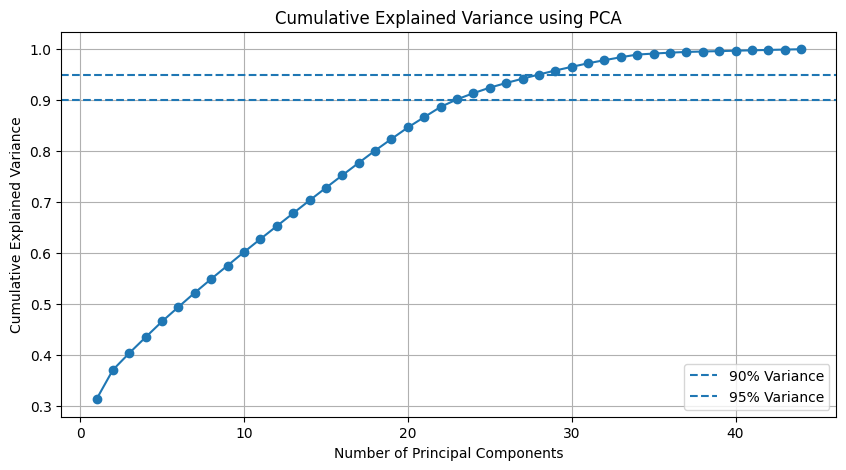

In [13]:
plt.figure(figsize=(10, 5))

plt.plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance,
    marker="o"
)

plt.axhline(
    y=0.90,
    linestyle="--",
    label="90% Variance"
)

plt.axhline(
    y=0.95,
    linestyle="--",
    label="95% Variance"
)

plt.title("Cumulative Explained Variance using PCA")
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.legend()
plt.grid(True)
plt.show()

In [14]:
# Number of components required to retain at least 95% variance
components_95 = np.argmax(cumulative_variance >= 0.95) + 1

print(
    "Components required to retain at least 95% variance:",
    components_95
)

Components required to retain at least 95% variance: 28


## PCA to 2 Dimensions

Two principal components are used to create a 2D visualization of the high-dimensional student data.

In [15]:
pca_2d = PCA(n_components=2)

X_pca_2d = pca_2d.fit_transform(X_scaled)

print("Original number of features:", X_scaled.shape[1])
print("Reduced number of features:", X_pca_2d.shape[1])

print(
    "Variance explained by PC1 and PC2:",
    round(pca_2d.explained_variance_ratio_.sum(), 4)
)

Original number of features: 44
Reduced number of features: 2
Variance explained by PC1 and PC2: 0.3714


In [16]:
pca_df = pd.DataFrame(
    X_pca_2d,
    columns=["PC1", "PC2"]
)

display(pca_df.head())

,PC1,PC2
0,-2.352407,0.823926
1,-5.842807,-0.723244
2,-3.156160,1.910488
3,0.036408,-1.128912
4,3.429420,0.058402


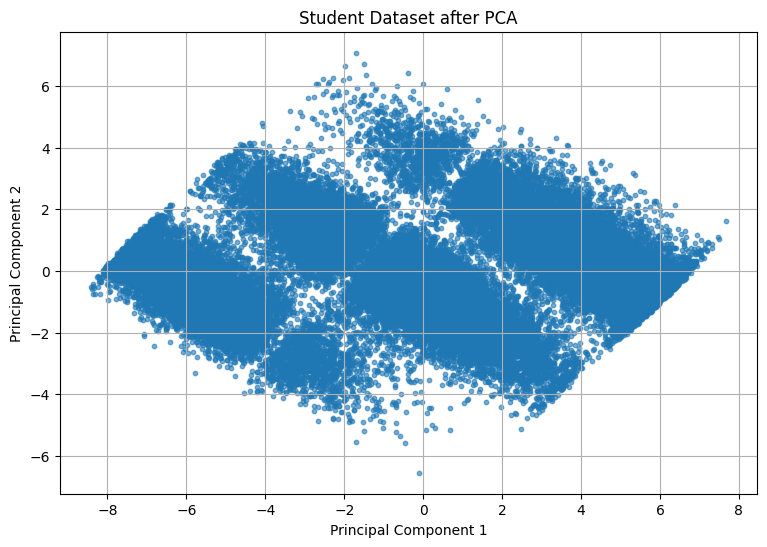

In [17]:
plt.figure(figsize=(9, 6))

plt.scatter(
    pca_df["PC1"],
    pca_df["PC2"],
    s=10,
    alpha=0.6
)

plt.title("Student Dataset after PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(True)
plt.show()

# PCA Component Interpretation

The loading values indicate how strongly each original feature contributes to each principal component.

In [18]:
loadings = pd.DataFrame(
    pca_2d.components_.T,
    index=X.columns,
    columns=["PC1", "PC2"]
)

print("Top features contributing to PC1:")
display(
    loadings["PC1"]
    .abs()
    .sort_values(ascending=False)
    .head(10)
    .to_frame("Absolute Loading")
)

print("Top features contributing to PC2:")
display(
    loadings["PC2"]
    .abs()
    .sort_values(ascending=False)
    .head(10)
    .to_frame("Absolute Loading")
)

Top features contributing to PC1:


,Absolute Loading
SGPA_Sem8,0.253247
SGPA_Sem7,0.252208
SGPA_Sem6,0.251002
SGPA_Sem5,0.249764
SGPA_Sem4,0.248465
SGPA_Sem3,0.247111
SGPA_Sem2,0.245724
CGPA,0.244187
SGPA_Sem1,0.244071
CGPA_Tier_Low,0.211129


Top features contributing to PC2:


,Absolute Loading
CodingTestScore,0.256076
AptitudeTestScore,0.248227
Projects,0.244238
SGPA_Sem1,0.235500
Internships,0.230544
AttendancePercent,0.227238
SGPA_Sem2,0.227074
Certifications,0.224110
MockInterviewScore,0.220815
SGPA_Sem3,0.219416


# Part B — Anomaly Detection

Anomaly detection identifies observations that are significantly different from the majority of the dataset.

We use two methods:

1. **Isolation Forest**
2. **Local Outlier Factor (LOF)**

## 1. Isolation Forest

Isolation Forest isolates observations by randomly selecting features and split values.

Anomalous observations tend to be isolated more quickly than normal observations.

In [19]:
isolation_model = IsolationForest(
    n_estimators=200,
    contamination="auto",
    random_state=42,
    n_jobs=-1
)

isolation_labels = isolation_model.fit_predict(X_scaled)

# Isolation Forest returns:
#  1  = normal
# -1  = anomaly

df_isolation = df.copy()

df_isolation["IsolationForest_Label"] = isolation_labels

df_isolation["IsolationForest_Anomaly"] = np.where(
    isolation_labels == -1,
    "Anomaly",
    "Normal"
)

print("Isolation Forest completed!")

print("\nCounts:")
print(df_isolation["IsolationForest_Anomaly"].value_counts())

Isolation Forest completed!

Counts:
IsolationForest_Anomaly
Normal     34771
Anomaly    15229
Name: count, dtype: int64


In [20]:
isolation_scores = isolation_model.decision_function(X_scaled)

df_isolation["IsolationForest_Score"] = isolation_scores

print("Most anomalous observations according to Isolation Forest:")
display(
    df_isolation
    .sort_values("IsolationForest_Score")
    .head(10)
)

Most anomalous observations according to Isolation Forest:


,StudentID,Gender,City,CollegeTier,Stream,Specialisation,Hostel,HistoryOfBacklogs,SGPA_Sem1,SGPA_Sem2,...,CodingTestScore,MockInterviewScore,ExtraCurricular,CGPA_Tier,PlacementStatus,IsAnomaly,Salary Package,IsolationForest_Label,IsolationForest_Anomaly,IsolationForest_Score
28064,28065,Male,Pune,Tier2,EE,Networking,Yes,Yes,4.46,4.69,...,99.0,30.7,0,Low,0,1,0.0,-1,Anomaly,-0.111391
4749,4750,Male,Pune,Tier3,EE,Networking,No,Yes,4.37,4.07,...,98.5,32.9,0,Low,0,1,0.0,-1,Anomaly,-0.108425
2427,2428,Male,Kochi,Tier3,CS,Networking,No,Yes,4.08,4.00,...,98.4,27.5,1,Low,0,1,0.0,-1,Anomaly,-0.103390
9770,9771,Female,Kochi,Tier3,Mechanical,DataScience,Yes,Yes,4.61,4.37,...,97.6,43.4,1,Low,0,1,0.0,-1,Anomaly,-0.101738
43764,43765,Male,Jaipur,Tier2,ECE,DataScience,Yes,Yes,4.28,4.00,...,95.9,30.1,0,Low,0,1,0.0,-1,Anomaly,-0.101639
47868,47869,Male,Chennai,Tier3,ECE,Networking,Yes,Yes,4.00,4.00,...,96.8,24.7,1,Low,0,1,0.0,-1,Anomaly,-0.101637
35341,35342,Male,Bangalore,Tier3,Civil,Embedded,Yes,Yes,4.55,4.25,...,96.5,28.3,0,Low,0,1,0.0,-1,Anomaly,-0.099885
48147,48148,Female,Mumbai,Tier3,ECE,Embedded,Yes,Yes,4.00,4.00,...,96.5,34.5,1,Low,0,1,0.0,-1,Anomaly,-0.099013
9760,9761,Female,Bangalore,Tier2,Mechanical,DataScience,Yes,Yes,4.12,4.79,...,95.8,30.3,0,Low,0,1,0.0,-1,Anomaly,-0.098550
15196,15197,Female,Mumbai,Tier3,ECE,DataScience,No,No,4.27,4.00,...,98.2,27.7,0,Low,0,1,0.0,-1,Anomaly,-0.097942


## 2. Local Outlier Factor (LOF)

LOF compares the local density of a data point with the density of its neighbors.

A point with substantially lower local density than its neighbors can be considered an anomaly.

In [21]:
lof_model = LocalOutlierFactor(
    n_neighbors=20,
    contamination="auto",
    n_jobs=-1
)

lof_labels = lof_model.fit_predict(X_scaled)

# LOF returns:
#  1  = normal
# -1  = anomaly

df_lof = df.copy()

df_lof["LOF_Label"] = lof_labels

df_lof["LOF_Anomaly"] = np.where(
    lof_labels == -1,
    "Anomaly",
    "Normal"
)

print("LOF completed!")

print("\nCounts:")
print(df_lof["LOF_Anomaly"].value_counts())

LOF completed!

Counts:
LOF_Anomaly
Normal     49999
Anomaly        1
Name: count, dtype: int64


In [22]:
# LOF negative_outlier_factor_: lower values indicate stronger outlier behavior
lof_scores = lof_model.negative_outlier_factor_

df_lof["LOF_Score"] = lof_scores

print("Most anomalous observations according to LOF:")
display(
    df_lof
    .sort_values("LOF_Score")
    .head(10)
)

Most anomalous observations according to LOF:


,StudentID,Gender,City,CollegeTier,Stream,Specialisation,Hostel,HistoryOfBacklogs,SGPA_Sem1,SGPA_Sem2,...,CodingTestScore,MockInterviewScore,ExtraCurricular,CGPA_Tier,PlacementStatus,IsAnomaly,Salary Package,LOF_Label,LOF_Anomaly,LOF_Score
4606,4607,Female,Bangalore,Tier2,Mechanical,Networking,Yes,No,7.11,6.86,...,97.5,27.1,0,Mid,0,1,0.00,-1,Anomaly,-1.501957
39776,39777,Female,Jaipur,Tier1,CS,AI,Yes,No,7.37,7.16,...,4.6,66.7,0,Mid,1,1,8.43,1,Normal,-1.471418
47054,47055,Female,Chennai,Tier2,Mechanical,Embedded,No,No,5.55,5.56,...,8.4,65.8,1,Low,1,1,5.56,1,Normal,-1.471139
12445,12446,Male,Pune,Tier2,Mechanical,DataScience,No,No,6.94,7.51,...,NaN,70.5,1,Mid,1,1,8.84,1,Normal,-1.457894
36725,36726,Female,Chennai,Tier2,CS,Embedded,Yes,Yes,8.15,7.27,...,6.4,82.2,1,Mid,1,1,8.20,1,Normal,-1.444419
27990,27991,Female,Mumbai,Tier1,CS,DataScience,Yes,Yes,9.75,10.00,...,NaN,80.3,1,High,1,1,18.12,1,Normal,-1.432395
8592,8593,Male,Hyderabad,Tier3,CS,DataScience,Yes,No,7.42,7.74,...,NaN,NaN,0,Mid,1,1,8.25,1,Normal,-1.402076
8307,8308,Male,Kolkata,Tier1,Mechanical,Embedded,Yes,Yes,6.72,6.91,...,NaN,72.8,1,Mid,1,1,8.14,1,Normal,-1.400253
34841,34842,Female,Jaipur,Tier2,CS,AI,No,No,6.09,5.16,...,2.7,94.6,1,Low,1,1,5.12,1,Normal,-1.398654
37713,37714,Female,Bangalore,Tier2,CS,DataScience,Yes,No,7.93,8.17,...,NaN,69.6,1,Mid,1,1,8.15,1,Normal,-1.398174


# Visualize Anomalies using PCA

PCA provides a two-dimensional representation so we can visualize where the detected anomalies occur.

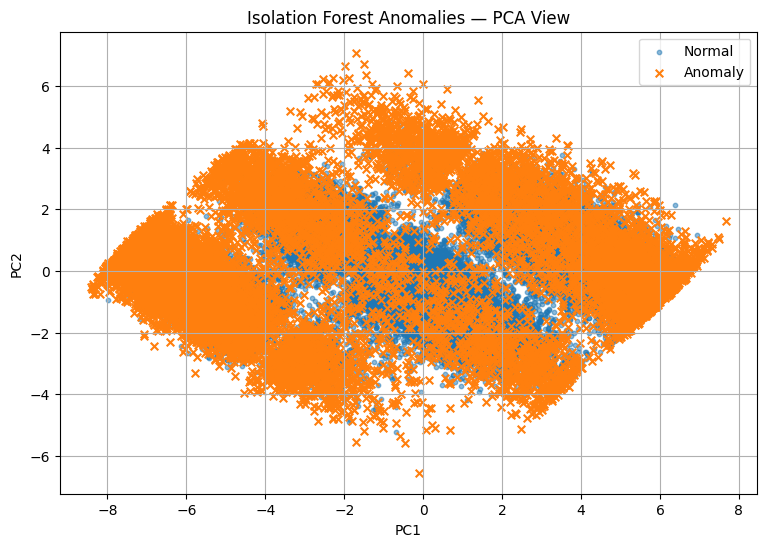

In [23]:
# Isolation Forest visualization
plt.figure(figsize=(9, 6))

normal_mask = isolation_labels == 1
anomaly_mask = isolation_labels == -1

plt.scatter(
    X_pca_2d[normal_mask, 0],
    X_pca_2d[normal_mask, 1],
    s=10,
    alpha=0.5,
    label="Normal"
)

plt.scatter(
    X_pca_2d[anomaly_mask, 0],
    X_pca_2d[anomaly_mask, 1],
    s=30,
    marker="x",
    label="Anomaly"
)

plt.title("Isolation Forest Anomalies — PCA View")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.grid(True)
plt.show()

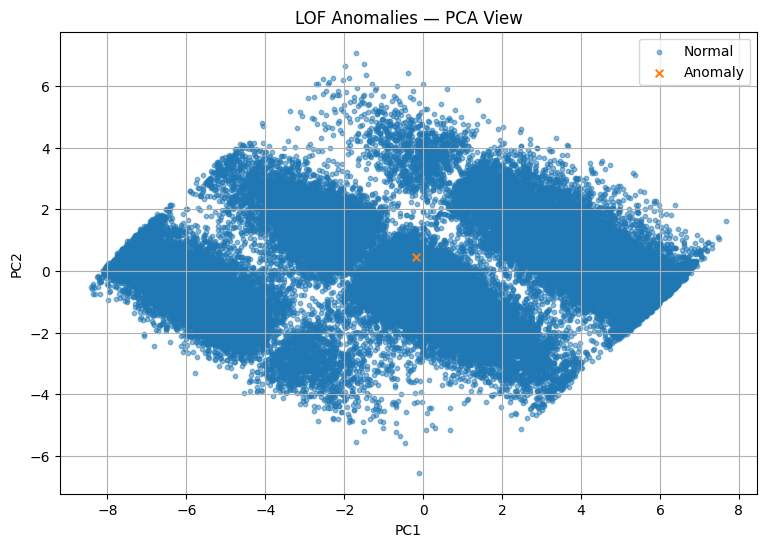

In [24]:
# LOF visualization
plt.figure(figsize=(9, 6))

normal_mask = lof_labels == 1
anomaly_mask = lof_labels == -1

plt.scatter(
    X_pca_2d[normal_mask, 0],
    X_pca_2d[normal_mask, 1],
    s=10,
    alpha=0.5,
    label="Normal"
)

plt.scatter(
    X_pca_2d[anomaly_mask, 0],
    X_pca_2d[anomaly_mask, 1],
    s=30,
    marker="x",
    label="Anomaly"
)

plt.title("LOF Anomalies — PCA View")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.grid(True)
plt.show()

# Compare Anomaly Detection Methods

In [25]:
isolation_anomaly_count = np.sum(isolation_labels == -1)
lof_anomaly_count = np.sum(lof_labels == -1)

anomaly_comparison = pd.DataFrame({
    "Method": ["Isolation Forest", "LOF"],
    "Normal Points": [
        np.sum(isolation_labels == 1),
        np.sum(lof_labels == 1)
    ],
    "Anomalies": [
        isolation_anomaly_count,
        lof_anomaly_count
    ],
    "Anomaly Percentage": [
        isolation_anomaly_count / len(isolation_labels) * 100,
        lof_anomaly_count / len(lof_labels) * 100
    ]
})

display(anomaly_comparison)

,Method,Normal Points,Anomalies,Anomaly Percentage
0,Isolation Forest,34771,15229,30.458
1,LOF,49999,1,0.002


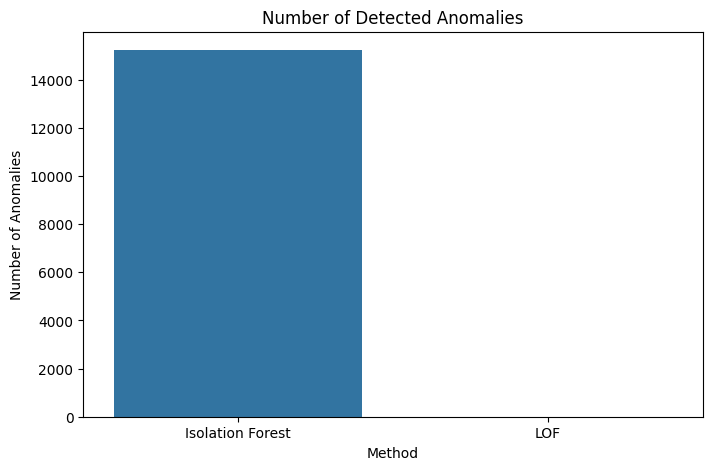

In [26]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=anomaly_comparison,
    x="Method",
    y="Anomalies"
)

plt.title("Number of Detected Anomalies")
plt.xlabel("Method")
plt.ylabel("Number of Anomalies")
plt.show()

# Compare the Detected Anomalies

We can check how many students were identified as anomalies by both methods.

In [27]:
both_anomaly = (
    (isolation_labels == -1) &
    (lof_labels == -1)
)

isolation_only = (
    (isolation_labels == -1) &
    (lof_labels == 1)
)

lof_only = (
    (isolation_labels == 1) &
    (lof_labels == -1)
)

normal_both = (
    (isolation_labels == 1) &
    (lof_labels == 1)
)

overlap_summary = pd.DataFrame({
    "Category": [
        "Anomaly in Both",
        "Isolation Forest Only",
        "LOF Only",
        "Normal in Both"
    ],
    "Count": [
        both_anomaly.sum(),
        isolation_only.sum(),
        lof_only.sum(),
        normal_both.sum()
    ]
})

display(overlap_summary)

,Category,Count
0,Anomaly in Both,1
1,Isolation Forest Only,15228
2,LOF Only,0
3,Normal in Both,34771


# Final Dataset with Anomaly Results

The original data is combined with the anomaly labels from both methods.

In [28]:
final_results = df.copy()

final_results["IsolationForest_Anomaly"] = np.where(
    isolation_labels == -1,
    "Anomaly",
    "Normal"
)

final_results["LOF_Anomaly"] = np.where(
    lof_labels == -1,
    "Anomaly",
    "Normal"
)

final_results["PCA_PC1"] = X_pca_2d[:, 0]
final_results["PCA_PC2"] = X_pca_2d[:, 1]

display(final_results.head())

,StudentID,Gender,City,CollegeTier,Stream,Specialisation,Hostel,HistoryOfBacklogs,SGPA_Sem1,SGPA_Sem2,...,MockInterviewScore,ExtraCurricular,CGPA_Tier,PlacementStatus,IsAnomaly,Salary Package,IsolationForest_Anomaly,LOF_Anomaly,PCA_PC1,PCA_PC2
0,1,Male,Ahmedabad,Tier2,ECE,Networking,No,No,6.02,6.54,...,47.8,0,Low,0,0,0.00,Normal,Normal,-2.352407,0.823926
1,2,Female,Mumbai,Tier2,ECE,DataScience,Yes,Yes,5.84,5.12,...,25.8,0,Low,0,0,0.00,Anomaly,Normal,-5.842807,-0.723244
2,3,Male,Kolkata,Tier2,IT,DataScience,Yes,No,4.91,5.29,...,41.5,0,Low,1,0,3.89,Normal,Normal,-3.156160,1.910488
3,4,Male,Jaipur,Tier1,CS,AI,No,No,7.67,8.03,...,48.0,0,Mid,1,0,8.37,Normal,Normal,0.036408,-1.128912
4,5,Male,Pune,Tier2,IT,DataScience,Yes,No,8.14,8.97,...,61.7,1,High,1,0,18.99,Normal,Normal,3.429420,0.058402


In [29]:
print("Final dataset shape:", final_results.shape)

print("\nIsolation Forest:")
print(final_results["IsolationForest_Anomaly"].value_counts())

print("\nLOF:")
print(final_results["LOF_Anomaly"].value_counts())

Final dataset shape: (50000, 36)

Isolation Forest:
IsolationForest_Anomaly
Normal     34771
Anomaly    15229
Name: count, dtype: int64

LOF:
LOF_Anomaly
Normal     49999
Anomaly        1
Name: count, dtype: int64


In [30]:
print("========== FINAL SUMMARY ==========")
print("Original feature count:", X_scaled.shape[1])
print("PCA components for 95% variance:", components_95)
print("Variance retained by PC1 + PC2:", round(
    pca_2d.explained_variance_ratio_.sum(), 4
))

print("\nIsolation Forest anomalies:", isolation_anomaly_count)
print("LOF anomalies:", lof_anomaly_count)
print("Anomalies detected by both:", both_anomaly.sum())

print("===================================")

========== FINAL SUMMARY ==========
Original feature count: 44
PCA components for 95% variance: 28
Variance retained by PC1 + PC2: 0.3714

Isolation Forest anomalies: 15229
LOF anomalies: 1
Anomalies detected by both: 1
